In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage

# load galaxy dataset

In [ ]:
from galaxy_datasets import gz_candels 

catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [ ]:
cols = catalog.columns.to_numpy()

# initial testing

In [ ]:
from ml_sandbox.dataset import load_image
import numpy as np
im = load_image(catalog['filename'][0], dir='.tmp/')


In [ ]:
import torch

In [ ]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
# gzdataset = GalaxyDataset(
#     catalog,
#     label_cols=['merging-candels_merger'],  
#     # transform=ToTensor(),
#     target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
#     )

In [ ]:
from ml_sandbox.dataset import get_dataset
dataset_tr = get_dataset(catalog, label_cols=['merging-candels_merger'], size=1000, train=True, dir='.tmp/')

In [ ]:
for i in range(10):
    img, label = dataset_tr[i]
    print(f"Max value: {img.max()}, Min value: {img.min()}")

Max value: 3.9133143424987793, Min value: -0.6874369382858276
Max value: 9.358216285705566, Min value: -0.635565459728241
Max value: 6.278846263885498, Min value: -0.6874475479125977
Max value: 5.662678241729736, Min value: -0.6850671768188477
Max value: 6.918902397155762, Min value: -0.6859129071235657
Max value: 7.433582782745361, Min value: -0.6027508974075317
Max value: 5.089462757110596, Min value: -0.669850766658783
Max value: 5.065082550048828, Min value: -0.6874092817306519
Max value: 5.618692874908447, Min value: -0.6874475479125977
Max value: 7.780611515045166, Min value: -0.6866163611412048


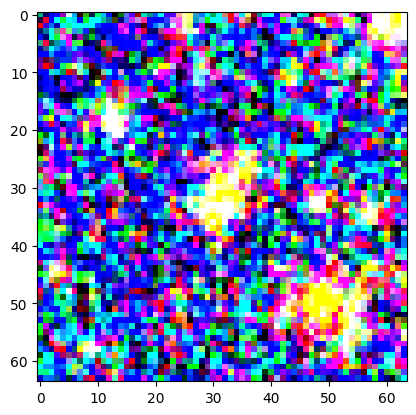

In [ ]:
im, lab = dataset_tr[5]
plt.imshow(im.permute(1,2,0))

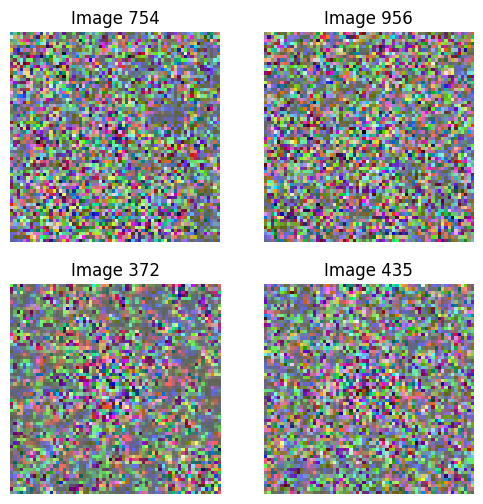

In [ ]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(dataset_tr, num_images=i+1)

# training

In [ ]:
catalog['merging-candels_merger'].max()+1

np.float64(59.0)

In [ ]:
from ml_sandbox.models import SimpleCNNClassifier
from ml_sandbox.train_eval import train_cnn, test_cnn
from ml_sandbox.dataset import get_dataloader
from sklearn.model_selection import train_test_split

model = SimpleCNNClassifier(num_classes=int(catalog['merging-candels_merger'].max()+1), input_channels=3)

train_cat, test_cat = train_test_split(catalog, test_size=0.2, random_state=42)

train_dataset = get_dataset(train_cat, label_cols=['merging-candels_merger'], size=None, train=True, dir='.tmp/')
test_dataset = get_dataset(test_cat, label_cols=['merging-candels_merger'], size=None, train=False, dir='.tmp/')

train_loader = get_dataloader(train_dataset, batch_size=8)
test_loader = get_dataloader(test_dataset, batch_size=8)

from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss()

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [ ]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels.dim())
    break

torch.Size([8, 3, 64, 64]) torch.Size([8])
1


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
device

device(type='cuda')

In [ ]:
for i in range(5):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    train_loss, train_acc = train_cnn(train_loader, model, criterion, optimizer, device=device) 
    test_loss, test_acc = test_cnn(test_loader, model, criterion, device=device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    print(f"Epoch: {i+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

loss: 4.087204  [    8/31712]


UnboundLocalError: cannot access local variable 'correct' where it is not associated with a value

In [ ]:
from ml_sandbox.train_eval import plot_training_history
plot_training_history(history)

tensor([[6.9963e+09],
        [3.4174e+09],
        [2.6189e+09],
        [6.5996e+09],
        [2.2414e+09],
        [2.6561e+09],
        [5.1489e+09],
        [1.9165e+09],
        [2.4844e+09],
        [1.3240e+10],
        [3.0722e+09],
        [2.0281e+09],
        [5.9011e+09],
        [3.7643e+09],
        [1.4227e+09],
        [3.7246e+09]], grad_fn=<AddmmBackward0>) tensor([0., 1., 5., 1., 1., 2., 0., 2., 3., 1., 2., 5., 1., 2., 0., 3.])


In [7]:
from ml_sandbox.models import make_pca_rf_pipeline
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
from ml_sandbox.dataset import convert_dataset_sklearn

X_train, y_train = convert_dataset_sklearn(train_dataset)
X_test, y_test = convert_dataset_sklearn(test_dataset)



In [9]:
import torchvision
from torchvision.transforms import ToTensor

In [8]:
model.fit(xtrain, ytrain)
test_accuracy = model.score(xtest, ytest)
print(f'Test Accuracy: {test_accuracy:.4f}')


ValueError: could not convert string to float: 'GDS_2171.jpg'